# Hands-on Session: ROAS Estimation with Double Machine Learning

## Introduction

In this notebook, we apply Double Machine Learning (DML) to estimate the Return on Ad Spend (ROAS) — the causal effect of advertising expenditure on revenue.

## Scenario

An e-commerce company runs targeted advertising campaigns and wants to evaluate their effectiveness. The marketing team has collected observational data on:
- Ad spend per user (continuous treatment)
- 30-day revenue generated by each user (continuous outcome)
- Various user characteristics

The challenge: Users who receive higher ad spend are not randomly selected — the bidding algorithm targets users based on their characteristics. This creates confounding that biases naive estimates of ROAS.

Let's start by importing the necessary packages.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import optuna

import statsmodels.api as sm
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import StackingRegressor
from lightgbm import LGBMRegressor

import doubleml as dml

import warnings
warnings.filterwarnings('ignore')

/Users/ruizhechao/Desktop/notes/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

Load the ROAS dataset and examine the available features.

In [4]:
url = 'https://trainings.doubleml.org/datasets/roas_data.csv'
df = pd.read_csv(url)

In [5]:
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 14)


,past_spend,days_since_visit,items_viewed,is_desktop,seg_new,seg_ret,seg_vip,browser_latency,post_click_engagement,competitor_activity,user_income,ad_spend,revenue,true_roas
0,47.873588,4.033967,7,0,False,True,False,94.780289,34.501205,0.807405,29.384011,3.046824,44.621197,2.347776
1,29.889295,1.446363,5,1,False,True,False,83.608463,28.149147,0.004040,62.841968,1.079656,50.408908,2.656745
2,27.645672,1.044395,5,0,False,True,False,97.724978,28.353103,0.106389,43.066659,0.943198,33.948697,2.756733
3,27.646046,1.638272,7,0,False,True,False,106.133185,8.905004,0.998263,34.542324,3.716817,25.833181,2.870659
4,92.994288,5.646521,3,0,False,False,True,79.093441,45.850025,0.648754,58.474466,4.629954,71.797952,1.599203


The dataset contains user-level observations with the following variables:

**Treatment & Outcome:**
- `ad_spend`: Marketing expenditure per user in dollars (continuous treatment)
- `revenue`: 30-day revenue generated by the user in dollars (continuous outcome)

**Confounders (affect both treatment and outcome):**
- `past_spend`: Historical spending by the user (highly skewed)
- `days_since_visit`: Days since last website visit
- `items_viewed`: Number of items viewed in current session
- `is_desktop`: Device type (1 = Desktop, 0 = Mobile)
- `seg_new`, `seg_ret`, `seg_vip`: User segment dummies (New, Returning, VIP)

**Special Variables:**
- `user_income`: User income (precision variable - affects Y only)
- `competitor_activity`: Competitor bidding intensity (instrument - affects D only)
- `browser_latency`: Technical noise variable (no causal relationship)
- `post_click_engagement`: Post-treatment variable (collider)
- `true_roas`: Oracle individual treatment effect (for evaluation only)

In [6]:
df.describe()

,past_spend,days_since_visit,items_viewed,is_desktop,browser_latency,post_click_engagement,competitor_activity,user_income,ad_spend,revenue,true_roas
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,32.300886,76.517615,4.00950,0.394000,99.901564,20.565408,0.502429,49.990680,1.837131,32.928742,2.309717
std,29.786710,141.770442,2.00968,0.488659,19.934824,17.317360,0.289304,14.929481,2.373274,25.872649,0.634349
min,0.000000,0.000039,0.00000,0.000000,20.013355,0.000000,0.000028,10.000000,0.100000,0.000000,0.111357
25%,8.685637,2.576802,3.00000,0.000000,86.464528,7.845277,0.249710,39.851554,0.499947,15.403376,1.837540
50%,26.335808,6.692257,4.00000,0.000000,99.787206,18.279441,0.503075,49.909394,1.191380,31.027928,2.311678
75%,47.716771,18.692477,5.00000,1.000000,113.231211,28.561218,0.756944,60.109543,2.253642,46.271690,2.770406
max,272.204654,365.000000,14.00000,1.000000,167.670514,136.139668,0.999775,106.492701,20.000000,180.441778,4.226050


### Causal Structure (DAG)

The following Directed Acyclic Graph (DAG) illustrates the causal relationships in our data:


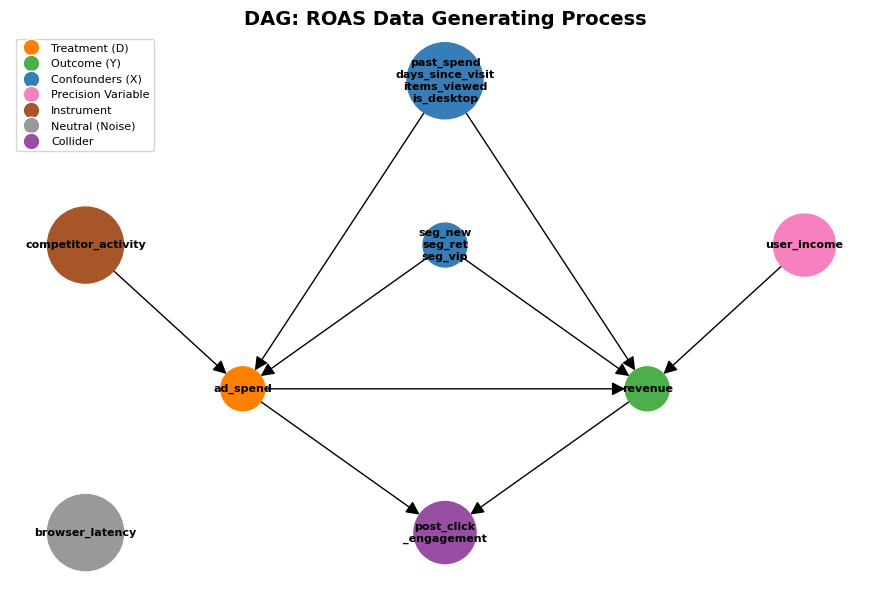

In [7]:
plt.rcParams['figure.figsize'] = 9., 6
G = nx.DiGraph()

# Define node names
treatment_name = 'ad_spend'
outcome_name = 'revenue'
confounders = 'past_spend\ndays_since_visit\nitems_viewed\nis_desktop'
segments = 'seg_new\nseg_ret\nseg_vip'
precision_var = 'user_income'
instrument = 'competitor_activity'
neutral = 'browser_latency'
collider = 'post_click\n_engagement'

# Add nodes and edges
for node in [treatment_name, outcome_name, confounders, segments, precision_var, instrument, neutral, collider]:
    G.add_node(node)

G.add_edges_from([
    (confounders, treatment_name), (confounders, outcome_name),
    (segments, treatment_name), (segments, outcome_name),
    (treatment_name, outcome_name),
    (precision_var, outcome_name),
    (instrument, treatment_name),
    (treatment_name, collider), (outcome_name, collider)
])

# Layout and colors
pos = {
    treatment_name: (0, 0), outcome_name: (1.8, 0),
    confounders: (0.9, 1.5), segments: (0.9, 0.7),
    precision_var: (2.5, 0.7), instrument: (-0.7, 0.7),
    neutral: (-0.7, -0.7), collider: (0.9, -0.7)
}

colors = {'blue': '#377eb8', 'orange': '#ff7f00', 'green': '#4daf4a', 
          'pink': '#f781bf', 'brown': '#a65628', 'purple': '#984ea3', 'gray': '#999999'}

base_size = 1000
size = [base_size, base_size, 3*base_size, base_size, 2*base_size, 3*base_size, 3*base_size, 2*base_size]
color_map = [colors['orange'], colors['green'], colors['blue'], colors['blue'], 
             colors['pink'], colors['brown'], colors['gray'], colors['purple']]

nx.draw_networkx(G, pos, with_labels=True, node_size=size, node_color=color_map,
                 font_size=8, font_weight='bold', arrowsize=20,
                 min_source_margin=15, min_target_margin=15)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['orange'], markersize=12, label='Treatment (D)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['green'], markersize=12, label='Outcome (Y)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['blue'], markersize=12, label='Confounders (X)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['pink'], markersize=12, label='Precision Variable'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['brown'], markersize=12, label='Instrument'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['gray'], markersize=12, label='Neutral (Noise)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['purple'], markersize=12, label='Collider'),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=8)
plt.title('DAG: ROAS Data Generating Process', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### Exploratory Data Analysis

Let's visualize the distributions of treatment, outcome, and the true treatment effects.

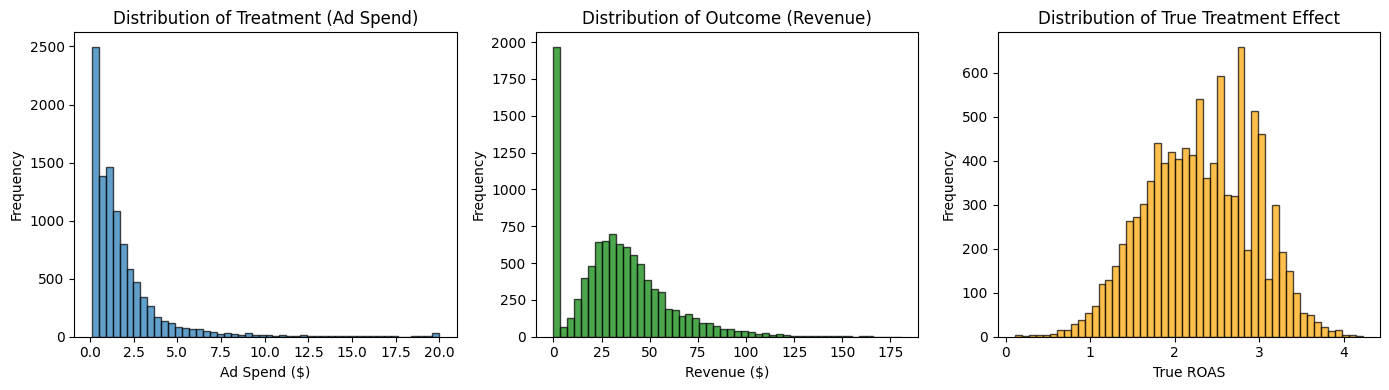

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Treatment distribution
axes[0].hist(df['ad_spend'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Ad Spend ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Treatment (Ad Spend)')

# Outcome distribution
axes[1].hist(df['revenue'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Revenue ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Outcome (Revenue)')

# True ROAS distribution
axes[2].hist(df['true_roas'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_xlabel('True ROAS')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of True Treatment Effect')

plt.tight_layout()
plt.show()

## Baseline: True ATE and Naive Estimation

Before applying DML, let's establish our benchmarks:
1. **True ATE**: The oracle average treatment effect (available because this is simulated data)
2. **Naive OLS**: Simple regression of revenue on ad spend (ignoring confounding). This is equivalent to comparing averages if treatment is binary.

In [22]:
# Define key variables
outcome = 'revenue'
treatment = 'ad_spend'
confounders = ['past_spend', 'days_since_visit', 'items_viewed', 'is_desktop', 
               'seg_new', 'seg_ret', 'seg_vip']

# True Average Treatment Effect (Oracle)
true_ate = df['true_roas'].mean()
print(f"True Average ROAS: {true_ate:.4f}")

True Average ROAS: 2.3097


In [23]:
# Naive OLS: Revenue = alpha + beta * Ad_Spend + error

X = sm.add_constant(df[[treatment]])
ols_model = sm.OLS(df[outcome], X).fit()
naive_roas = ols_model.params[treatment]
naive_roas_se = ols_model.bse[treatment]

print(ols_model.summary())
print(f"Naive ROAS Estimate: {naive_roas:.4f}")
print(f"Bias: {abs(naive_roas - true_ate):.4f}")

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                 2.307e+04
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:35:03   Log-Likelihood:                -40740.
No. Observations:               10000   AIC:                         8.148e+04
Df Residuals:                    9998   BIC:                         8.150e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.2005      0.180     90.042      0.0

In [24]:
X = sm.add_constant(df[[treatment] + confounders])
X = X.astype(float)

ols_model = sm.OLS(df[outcome], X).fit()
linear_roas = ols_model.params[treatment]
linear_roas_se = ols_model.bse[treatment]

print(ols_model.summary())
print(f"Linear ROAS Estimate: {linear_roas:.4f}")
print(f"Bias: {abs(linear_roas - true_ate):.4f}")

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 2.093e+04
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:35:03   Log-Likelihood:                -32964.
No. Observations:               10000   AIC:                         6.594e+04
Df Residuals:                    9992   BIC:                         6.600e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.3126      0.237  

## Double Machine Learning Workflow

We follow the standard [DoubleML Workflow](https://docs.doubleml.org/stable/workflow/workflow.html):

1. **Data-Backend**: Prepare the `DoubleMLData` object
2. **Causal Model**: Choose the appropriate model (PLR for continuous treatment)
3. **ML Methods**: Select learners for nuisance functions
4. **DML Specification**: Initialize and parametrize the DML model
5. **Hyperparameter Tuning**: Optimize model parameters
6. **Estimation**: Fit the model
7. **Inference**: Confidence intervals and hypothesis tests

### Step 1: Data-Backend

We create a `DoubleMLData` object specifying the outcome, treatment, and confounders.

In [10]:
dml_data = dml.DoubleMLData(
    data=df,
    y_col=outcome,
    d_cols=treatment,
    x_cols=confounders
)
print(dml_data)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: revenue
Treatment variable(s): ['ad_spend']
Covariates: ['past_spend', 'days_since_visit', 'items_viewed', 'is_desktop', 'seg_new', 'seg_ret', 'seg_vip']
Instrument variable(s): None
No. Observations: 10000
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 14 entries, past_spend to true_roas
dtypes: bool(3), float64(9), int64(2)
memory usage: 888.8 KB



### Step 2: Causal Model

Since we have a **continuous treatment** (ad spend) and **continuous outcome** (revenue), we use the **Partially Linear Regression (PLR)** model:

$$Y = D \cdot \theta_0 + g_0(X) + \epsilon$$

where:
- $\theta_0$ is the causal effect (average ROAS) we want to estimate
- $g_0(X)$ is the baseline outcome function
- $D = m_0(X) + V$ is the treatment assignment

### Step 3: ML Methods

We need learners for two nuisance functions:
- `ml_l`: Predicts $\mathbb{E}[Y|X]$ (outcome regression)
- `ml_m`: Predicts $\mathbb{E}[D|X]$ (treatment regression)

We'll compare Linear Regression (baseline) with LightGBM (flexible).

In [11]:
# Linear learners
ml_l_linear = LinearRegression()
ml_m_linear = LinearRegression()

# Boosting learners
ml_l_boost = LGBMRegressor(random_state=42, verbose=-1)
ml_m_boost = LGBMRegressor(random_state=42, verbose=-1)

### Step 4: DML Specification

We initialize the DoubleMLPLR model with key hyperparameters:
- `n_folds`: Number of folds for cross-fitting (default: 5)
- `n_rep`: Number of repetitions for cross-fitting (default: 1)
- `score`: Score function to use (default: 'partialling out')

In [12]:
# Linear DML
np.random.seed(42)
dml_linear = dml.DoubleMLPLR(
    obj_dml_data=dml_data,
    ml_l=ml_l_linear,
    ml_m=ml_m_linear,
    n_folds=5,
)

Lets create two separate models in boosting to highlight hyperparameter tuning.

In [13]:
# Boosting DML
dml_boost = dml.DoubleMLPLR(
    obj_dml_data=dml_data,
    ml_l=LGBMRegressor(random_state=42, verbose=-1),
    ml_m=LGBMRegressor(random_state=42, verbose=-1),
    n_folds=5,
)

# Boosting DML (untuned) - using default hyperparameters
np.random.seed(42)
dml_boost_untuned = dml.DoubleMLPLR(
    obj_dml_data=dml_data,
    ml_l=LGBMRegressor(random_state=42, verbose=-1),
    ml_m=LGBMRegressor(random_state=42, verbose=-1),
    n_folds=5,
)

It is also possible to use ``sklearn.pipelines``.

In [14]:
base_regressors = [
    ('linear_regression', LinearRegression()),
    ('lgbm', LGBMRegressor(random_state=42, verbose=-1))
]

stacking_regressor = StackingRegressor(
    estimators=base_regressors,
    final_estimator=Ridge()
)

reg_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('stacking', stacking_regressor)
])
reg_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('stacking', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False
,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('linear_regression', ...), ('lgbm', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()


In [15]:
# Pipeline DML
dml_pipe = dml.DoubleMLPLR(
    obj_dml_data=dml_data,
    ml_l=clone(reg_pipeline),
    ml_m=clone(reg_pipeline),
    n_folds=5,
)

# Pipeline DML (untuned) - using default hyperparameters
dml_pipe_untuned = dml.DoubleMLPLR(
    obj_dml_data=dml_data,
    ml_l=clone(reg_pipeline),
    ml_m=clone(reg_pipeline),
    n_folds=5,
)


### Step 5: Hyperparameter Tuning

For the boosting model, we use Optuna to tune the hyperparameters of the nuisance learners. This can significantly improve the quality of the nuisance estimates.

In [16]:
# Define parameter space for outcome regression (ml_l)
def ml_boost_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': -1,
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 20, step=5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0, step=0.1),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 10.0, log=True),
    }

param_space = {
    # we are reusing the same parameter space for both ml_l and ml_m
    'ml_l': ml_boost_params,
    'ml_m': ml_boost_params
}

In [17]:
# Optuna settings
optuna_settings = {
    'n_trials': 20,  # smaller number of trials for illustration
    'show_progress_bar': True,
    'verbosity': optuna.logging.WARNING,
}

np.random.seed(42)
# Tune the model
print("Tuning hyperparameters...")
dml_boost.tune_ml_models(
    ml_param_space=param_space,
    optuna_settings=optuna_settings,
)

print("\nBest parameters found:")
print(f"ml_l: {dml_boost.params['ml_l']}")
print(f"ml_m: {dml_boost.params['ml_m']}")

Tuning hyperparameters...


Best trial: 15. Best value: -1.03644: 100%|██████████| 20/20 [03:23<00:00, 10.15s/it]


Best parameters found:
ml_l: {'ad_spend': [[{'n_estimators': 600, 'learning_rate': 0.021352321726097672, 'min_child_samples': 15, 'subsample': 1.0, 'colsample_bytree': 0.6, 'reg_alpha': 0.03784520433652804, 'reg_lambda': 0.010480836864955856}, {'n_estimators': 600, 'learning_rate': 0.021352321726097672, 'min_child_samples': 15, 'subsample': 1.0, 'colsample_bytree': 0.6, 'reg_alpha': 0.03784520433652804, 'reg_lambda': 0.010480836864955856}, {'n_estimators': 600, 'learning_rate': 0.021352321726097672, 'min_child_samples': 15, 'subsample': 1.0, 'colsample_bytree': 0.6, 'reg_alpha': 0.03784520433652804, 'reg_lambda': 0.010480836864955856}, {'n_estimators': 600, 'learning_rate': 0.021352321726097672, 'min_child_samples': 15, 'subsample': 1.0, 'colsample_bytree': 0.6, 'reg_alpha': 0.03784520433652804, 'reg_lambda': 0.010480836864955856}, {'n_estimators': 600, 'learning_rate': 0.021352321726097672, 'min_child_samples': 15, 'subsample': 1.0, 'colsample_bytree': 0.6, 'reg_alpha': 0.03784520433

This works similar with pipelines, just with a more complex hyperparameter space.

In [18]:
# parameter space for the outcome regression tuning
def ml_pipeline_params(trial):
    return {
        'stacking__lgbm__n_estimators':  trial.suggest_int('stacking__lgbm__n_estimators', 200, 1000, step=100),
        'stacking__lgbm__learning_rate': trial.suggest_float('stacking__lgbm__learning_rate', 0.01, 0.2, log=True),
        'stacking__lgbm__max_depth': -1,
        'stacking__lgbm__min_child_samples': trial.suggest_int('stacking__lgbm__min_child_samples', 5, 20, step=5),
        'stacking__lgbm__subsample': trial.suggest_float('stacking__lgbm__subsample', 0.6, 1.0, step=0.1),
        'stacking__lgbm__colsample_bytree': trial.suggest_float('stacking__lgbm__colsample_bytree', 0.6, 1.0, step=0.1),
        'stacking__lgbm__reg_alpha': trial.suggest_float('stacking__lgbm__reg_alpha', 1e-2, 10.0, log=True),
        'stacking__lgbm__reg_lambda': trial.suggest_float('stacking__lgbm__reg_lambda', 1e-2, 10.0, log=True),
        'stacking__final_estimator__alpha': trial.suggest_float('stacking__final_estimator__alpha', 0.001, 10.0, log=True),
    }

param_space_pipeline = {
    # we are reusing the same parameter space for both ml_g and ml_m
    'ml_l': ml_pipeline_params,
    'ml_m': ml_pipeline_params
}

In [19]:
np.random.seed(42)
# Tune the model
print("Tuning hyperparameters...")
dml_pipe.tune_ml_models(
    ml_param_space=param_space_pipeline,
    optuna_settings=optuna_settings,
)

print("\nBest parameters found:")
print(f"ml_l: {dml_pipe.params['ml_l']}")
print(f"ml_m: {dml_pipe.params['ml_m']}")

Tuning hyperparameters...


Best trial: 19. Best value: -1.0447: 100%|██████████| 20/20 [19:47<00:00, 59.39s/it] 


Best parameters found:
ml_l: {'ad_spend': [[{'stacking__lgbm__n_estimators': 700, 'stacking__lgbm__learning_rate': 0.016557544826348875, 'stacking__lgbm__min_child_samples': 20, 'stacking__lgbm__subsample': 0.9, 'stacking__lgbm__colsample_bytree': 0.6, 'stacking__lgbm__reg_alpha': 0.031927747317400425, 'stacking__lgbm__reg_lambda': 5.339184475718982, 'stacking__final_estimator__alpha': 0.005189323187666545}, {'stacking__lgbm__n_estimators': 700, 'stacking__lgbm__learning_rate': 0.016557544826348875, 'stacking__lgbm__min_child_samples': 20, 'stacking__lgbm__subsample': 0.9, 'stacking__lgbm__colsample_bytree': 0.6, 'stacking__lgbm__reg_alpha': 0.031927747317400425, 'stacking__lgbm__reg_lambda': 5.339184475718982, 'stacking__final_estimator__alpha': 0.005189323187666545}, {'stacking__lgbm__n_estimators': 700, 'stacking__lgbm__learning_rate': 0.016557544826348875, 'stacking__lgbm__min_child_samples': 20, 'stacking__lgbm__subsample': 0.9, 'stacking__lgbm__colsample_bytree': 0.6, 'stacking_

### Step 6: Estimation

Now we fit all models and obtain the causal effect estimates.

In [20]:
# Fit all models
print("Fitting Linear DML...")
dml_linear.fit()

print("\nFitting Untuned Boosting DML...")
dml_boost_untuned.fit()

print("\nFitting Tuned Boosting DML...")
dml_boost.fit()

print("\nFitting Untuned DML Pipeline...")
dml_pipe_untuned.fit()

print("\nFitting DML Pipeline...")
dml_pipe.fit()

print("\n" + "="*50)
print("ESTIMATION COMPLETE")
print("="*50)
print(f"Linear DML:             θ = {dml_linear.coef[0]:.4f} (SE: {dml_linear.se[0]:.4f})")
print(f"Boosting DML (untuned): θ = {dml_boost_untuned.coef[0]:.4f} (SE: {dml_boost_untuned.se[0]:.4f})")
print(f"Boosting DML (tuned):   θ = {dml_boost.coef[0]:.4f} (SE: {dml_boost.se[0]:.4f})")
print(f"Pipeline DML (untuned): θ = {dml_pipe_untuned.coef[0]:.4f} (SE: {dml_pipe_untuned.se[0]:.4f})")
print(f"Pipeline DML (tuned):   θ = {dml_pipe.coef[0]:.4f} (SE: {dml_pipe.se[0]:.4f})")
print(f"True ROAS:              θ = {true_ate:.4f}")

Fitting Linear DML...

Fitting Untuned Boosting DML...

Fitting Tuned Boosting DML...

Fitting Untuned DML Pipeline...

Fitting DML Pipeline...

ESTIMATION COMPLETE
Linear DML:             θ = 3.0551 (SE: 0.0689)
Boosting DML (untuned): θ = 2.2012 (SE: 0.0690)
Boosting DML (tuned):   θ = 2.2224 (SE: 0.0699)
Pipeline DML (untuned): θ = 2.1806 (SE: 0.0687)
Pipeline DML (tuned):   θ = 2.2947 (SE: 0.0692)
True ROAS:              θ = 2.3097


### Step 7: Inference

We can examine confidence intervals, conduct hypothesis tests, and assess the quality of our nuisance learners.

In [21]:
# Confidence intervals
print("95% Confidence Intervals:")
print(f"\nLinear DML:")
print(dml_linear.confint())

print(f"\nBoosting DML (untuned):")
print(dml_boost_untuned.confint())

print(f"\nBoosting DML (tuned):")
print(dml_boost.confint())



95% Confidence Intervals:

Linear DML:
             2.5 %    97.5 %
ad_spend  2.920004  3.190248

Boosting DML (untuned):
            2.5 %    97.5 %
ad_spend  2.06604  2.336337

Boosting DML (tuned):
             2.5 %    97.5 %
ad_spend  2.085422  2.359332


In [22]:
# Collect confidence intervals for all models
ci_results = pd.DataFrame({
    "Model": [
        "Linear DML",
        "Boosting DML (untuned)",
        "Boosting DML (tuned)",
        "Pipeline DML (untuned)",
        "Pipeline DML (tuned)"
    ],
    "Lower 95% CI": [
        dml_linear.confint().iloc[0, 0],
        dml_boost_untuned.confint().iloc[0, 0],
        dml_boost.confint().iloc[0, 0],
        dml_pipe_untuned.confint().iloc[0, 0],
        dml_pipe.confint().iloc[0, 0]
    ],
    "Upper 95% CI": [
        dml_linear.confint().iloc[0, 1],
        dml_boost_untuned.confint().iloc[0, 1],
        dml_boost.confint().iloc[0, 1],
        dml_pipe_untuned.confint().iloc[0, 1],
        dml_pipe.confint().iloc[0, 1]
    ]
})

print("95% Confidence Intervals for All Models:")
print(ci_results.round(4).to_string(index=False))

95% Confidence Intervals for All Models:
                 Model  Lower 95% CI  Upper 95% CI
            Linear DML        2.9200        3.1902
Boosting DML (untuned)        2.0660        2.3363
  Boosting DML (tuned)        2.0854        2.3593
Pipeline DML (untuned)        2.0460        2.3152
  Pipeline DML (tuned)        2.1591        2.4304


### Results Summary

Let's collect and compare all estimates. First, compare the cross-fitted performance of the nuisance learners.

In [23]:
# Collect RMSE for all models and both nuisance functions
nuisance_results = pd.DataFrame({
    "Model": [
        "Linear DML",
        "Boosting DML (untuned)",
        "Boosting DML (tuned)",
        "Pipeline DML (untuned)",
        "Pipeline DML (tuned)"
    ],
    "RMSE ml_l (outcome)": [
        dml_linear.nuisance_loss['ml_l'][0, 0],
        dml_boost_untuned.nuisance_loss['ml_l'][0, 0],
        dml_boost.nuisance_loss['ml_l'][0, 0],
        dml_pipe_untuned.nuisance_loss['ml_l'][0, 0],
        dml_pipe.nuisance_loss['ml_l'][0, 0]
    ],
    "RMSE ml_m (treatment)": [
        dml_linear.nuisance_loss['ml_m'][0, 0],
        dml_boost_untuned.nuisance_loss['ml_m'][0, 0],
        dml_boost.nuisance_loss['ml_m'][0, 0],
        dml_pipe_untuned.nuisance_loss['ml_m'][0, 0],
        dml_pipe.nuisance_loss['ml_m'][0, 0]
    ]
})

print("Nuisance Learner Performance (RMSE) for All Models:")
print(nuisance_results.round(4).to_string(index=False))

Nuisance Learner Performance (RMSE) for All Models:
                 Model  RMSE ml_l (outcome)  RMSE ml_m (treatment)
            Linear DML               7.8005                 1.3904
Boosting DML (untuned)               6.3251                 1.0506
  Boosting DML (tuned)               6.2646                 1.0386
Pipeline DML (untuned)               6.2666                 1.0501
  Pipeline DML (tuned)               6.2711                 1.0426


This is directly related to the estimation precision of the causal parameter.

In [24]:
# Collect all results
results = pd.DataFrame({
    "Model": [
        "True Value",
        "Naive OLS",
        "Linear OLS",
        "DML (Linear)",
        "DML (Boosting, Untuned)",
        "DML (Boosting, Tuned)",
        "DML (Pipeline, Untuned)",
        "DML (Pipeline, Tuned)"
    ],
    "ROAS Estimate": [
        true_ate,
        naive_roas,
        linear_roas,
        dml_linear.coef[0],
        dml_boost_untuned.coef[0],
        dml_boost.coef[0],
        dml_pipe_untuned.coef[0],
        dml_pipe.coef[0]
    ],
    "SE": [
        "--",
        naive_roas_se,
        linear_roas_se,
        dml_linear.se[0],
        dml_boost_untuned.se[0],
        dml_boost.se[0],
        dml_pipe_untuned.se[0],
        dml_pipe.se[0]
    ],
    "RMSE (ml_l)": [
        "--", "--", "--",
        dml_linear.nuisance_loss['ml_l'][0, 0],
        dml_boost_untuned.nuisance_loss['ml_l'][0, 0],
        dml_boost.nuisance_loss['ml_l'][0, 0],
        dml_pipe_untuned.nuisance_loss['ml_l'][0, 0],
        dml_pipe.nuisance_loss['ml_l'][0, 0]
    ],
    "RMSE (ml_m)": [
        "--", "--", "--",
        dml_linear.nuisance_loss['ml_m'][0, 0],
        dml_boost_untuned.nuisance_loss['ml_m'][0, 0],
        dml_boost.nuisance_loss['ml_m'][0, 0],
        dml_pipe_untuned.nuisance_loss['ml_m'][0, 0],
        dml_pipe.nuisance_loss['ml_m'][0, 0]
    ]
})

# Add bias column
results["Bias"] = results["ROAS Estimate"] - true_ate

print("=" * 70)
print("COMPARISON OF ESTIMATION METHODS")
print("=" * 70)
print(results.round(4).to_string(index=False))

COMPARISON OF ESTIMATION METHODS
                  Model  ROAS Estimate        SE RMSE (ml_l) RMSE (ml_m)    Bias
             True Value         2.3097        --          --          --  0.0000
              Naive OLS         9.1056  0.059951          --          --  6.7959
             Linear OLS         3.0565  0.047124          --          --  0.7468
           DML (Linear)         3.0551  0.068941    7.800488    1.390374  0.7454
DML (Boosting, Untuned)         2.2012  0.068955    6.325104    1.050615 -0.1085
  DML (Boosting, Tuned)         2.2224  0.069876    6.264649    1.038641 -0.0873
DML (Pipeline, Untuned)         2.1806  0.068668    6.266615    1.050117 -0.1291
  DML (Pipeline, Tuned)         2.2947  0.069224    6.271143    1.042604 -0.0150


## Impact of Different Covariate Sets

A critical aspect of causal inference is choosing the right conditioning set. Let's explore how different variable selections affect our (untuned boosting to reduce computation time):

1. **Confounders only** (baseline): Variables that affect both D and Y
2. **+ Noise controls** (`browser_latency`): Noise Variable
3. **+ Precision variable** (`user_income`): Affects Y only → can reduce variance
4. **+ Instrument** (`competitor_activity`): Affects D only → can increase variance
5. **+ Collider** (`post_click_engagement`): Affected by both D and Y → introduces bias!


In [25]:
np.random.seed(42)

# Store results for comparison
covariate_results = {}

# 1. Baseline: Confounders only (already computed)
covariate_results['Confounders Only'] = {
    'coef': dml_boost_untuned.coef[0],
    'se': dml_boost_untuned.se[0]
}

In [26]:
# 2. Add noise controls (browser_latency)
dml_data_noise = dml.DoubleMLData(
    df, y_col=outcome, d_cols=treatment,
    x_cols=confounders + ['browser_latency']
)
dml_noise = dml.DoubleMLPLR(dml_data_noise, 
                               ml_l=LGBMRegressor(random_state=42, verbose=-1),
                               ml_m=LGBMRegressor(random_state=42, verbose=-1))
dml_noise.fit()
covariate_results['+ Noise Controls'] = {
    'coef': dml_noise.coef[0],
    'se': dml_noise.se[0]
}
print(f"With noise controls: ROAS = {dml_noise.coef[0]:.4f}, SE = {dml_noise.se[0]:.4f}")

With noise controls: ROAS = 2.1887, SE = 0.0685


In [27]:
# 2. Add precision variable (user_income)
dml_data_precision = dml.DoubleMLData(
    df, y_col=outcome, d_cols=treatment,
    x_cols=confounders + ['user_income']
)
dml_precision = dml.DoubleMLPLR(dml_data_precision, 
                                 ml_l=LGBMRegressor(random_state=42, verbose=-1),
                                 ml_m=LGBMRegressor(random_state=42, verbose=-1))
dml_precision.fit()
covariate_results['+ Precision Variable'] = {
    'coef': dml_precision.coef[0],
    'se': dml_precision.se[0]
}
print(f"With precision variable: ROAS = {dml_precision.coef[0]:.4f}, SE = {dml_precision.se[0]:.4f}")

With precision variable: ROAS = 2.1506, SE = 0.0610


In [28]:
# 4. Add instrument (competitor_activity)
dml_data_instrument = dml.DoubleMLData(
    df, y_col=outcome, d_cols=treatment,
    x_cols=confounders + ['competitor_activity']
)
dml_instrument = dml.DoubleMLPLR(dml_data_instrument, 
                               ml_l=LGBMRegressor(random_state=42, verbose=-1),
                               ml_m=LGBMRegressor(random_state=42, verbose=-1))
dml_instrument.fit()
covariate_results['+ Instrument'] = {
    'coef': dml_instrument.coef[0],
    'se': dml_instrument.se[0]
}
print(f"With instrument: ROAS = {dml_instrument.coef[0]:.4f}, SE = {dml_instrument.se[0]:.4f}")

With instrument: ROAS = 2.1666, SE = 0.0798


In [29]:
# 5. Add collider (post_click_engagement) - THIS SHOULD INTRODUCE BIAS!
dml_data_collider = dml.DoubleMLData(
    df, y_col=outcome, d_cols=treatment,
    x_cols=confounders + ['post_click_engagement']
)
dml_collider = dml.DoubleMLPLR(dml_data_collider, 
                                ml_l=LGBMRegressor(random_state=42, verbose=-1),
                                ml_m=LGBMRegressor(random_state=42, verbose=-1))
dml_collider.fit()
covariate_results['+ Collider'] = {
    'coef': dml_collider.coef[0],
    'se': dml_collider.se[0]
}
print(f"With collider: ROAS = {dml_collider.coef[0]:.4f}, SE = {dml_collider.se[0]:.4f}")

With collider: ROAS = 0.4946, SE = 0.0812


In [30]:
# Summary table for covariate sets
cov_df = pd.DataFrame(covariate_results).T
cov_df['Bias'] = cov_df['coef'] - true_ate
cov_df['% Error'] = (cov_df['Bias'] / true_ate) * 100

print("\n" + "=" * 60)
print("IMPACT OF DIFFERENT COVARIATE SETS")
print("=" * 60)
print(f"True ROAS: {true_ate:.4f}\n")
print(cov_df.round(4))


IMPACT OF DIFFERENT COVARIATE SETS
True ROAS: 2.3097

                        coef      se    Bias  % Error
Confounders Only      2.2012  0.0690 -0.1085  -4.6988
+ Noise Controls      2.1887  0.0685 -0.1210  -5.2391
+ Precision Variable  2.1506  0.0610 -0.1591  -6.8874
+ Instrument          2.1666  0.0798 -0.1431  -6.1964
+ Collider            0.4946  0.0812 -1.8152 -78.5878


## Heterogeneous Treatment Effects

The average ROAS masks important heterogeneity. Different user segments may respond differently to advertising. Let's explore:

1. *True effect heterogeneity* in the data
2. *Group Average Treatment Effects (GATE)* by user segment
3. *Conditional Average Treatment Effects (CATE)*

### True Effect Heterogeneity

First, let's examine the true treatment effect heterogeneity across user segments.

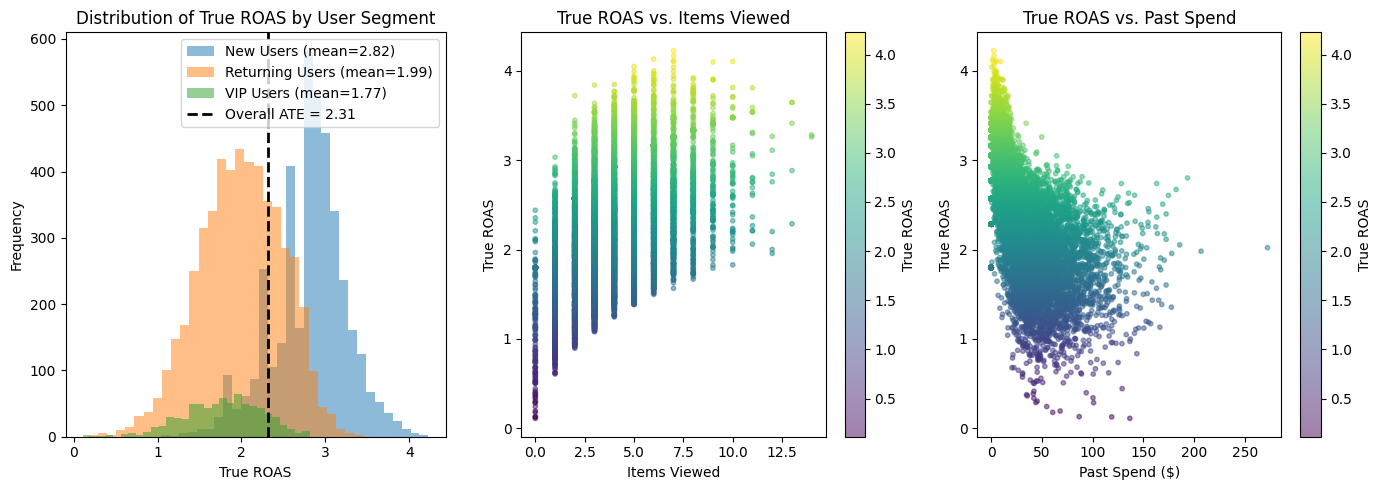

In [25]:
# True ROAS by user segment
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Distribution of true ROAS by segment
segments_list = ['seg_new', 'seg_ret', 'seg_vip']
segment_labels = ['New Users', 'Returning Users', 'VIP Users']

for seg, label in zip(segments_list, segment_labels):
    subset = df[df[seg] == 1]['true_roas']
    axes[0].hist(subset, bins=30, alpha=0.5, label=f'{label} (mean={subset.mean():.2f})')

axes[0].axvline(true_ate, color='black', linestyle='--', linewidth=2, label=f'Overall ATE = {true_ate:.2f}')
axes[0].set_xlabel('True ROAS')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of True ROAS by User Segment')
axes[0].legend()

# True ROAS vs items_viewed
scatter = axes[1].scatter(df['items_viewed'], df['true_roas'], c=df['true_roas'], 
                          cmap='viridis', alpha=0.5, s=10)
axes[1].set_xlabel('Items Viewed')
axes[1].set_ylabel('True ROAS')
axes[1].set_title('True ROAS vs. Items Viewed')
plt.colorbar(scatter, ax=axes[1], label='True ROAS')

# True ROAS vs past_spend
scatter = axes[2].scatter(df['past_spend'], df['true_roas'], c=df['true_roas'], 
                          cmap='viridis', alpha=0.5, s=10)
axes[2].set_xlabel('Past Spend ($)')
axes[2].set_ylabel('True ROAS')
axes[2].set_title('True ROAS vs. Past Spend')
plt.colorbar(scatter, ax=axes[2], label='True ROAS')

plt.tight_layout()
plt.show()

### Group Average Treatment Effects (GATE)

We use DoubleML's `gate()` method to estimate treatment effects for each user segment.

In [32]:
# Define groups based on user segments
groups = df[['seg_new', 'seg_ret', 'seg_vip']] == 1

# Estimate GATEs using the boosting model
gate_results = dml_boost.gate(groups=groups)

print("Group Average Treatment Effects (GATE):")
print(gate_results.summary)

Group Average Treatment Effects (GATE):
             coef   std err          t          P>|t|    [0.025    0.975]
seg_new  2.762214  0.301913   9.149043   5.744033e-20  2.170476  3.353953
seg_ret  2.413691  0.102140  23.631178  1.843276e-123  2.213500  2.613882
seg_vip  2.092440  0.098648  21.211201  7.526718e-100  1.899094  2.285787


In [33]:
# Compare estimated GATEs with true values
true_gate_values = [
    df.loc[df['seg_new'] == 1, 'true_roas'].mean(),
    df.loc[df['seg_ret'] == 1, 'true_roas'].mean(),
    df.loc[df['seg_vip'] == 1, 'true_roas'].mean()
]

# Create comparison table
gate_comparison = gate_results.summary.copy()
gate_comparison['True ROAS'] = true_gate_values
gate_comparison['Bias'] = gate_comparison['coef'] - gate_comparison['True ROAS']

print("\nComparison with True Values:")
print(gate_comparison[['coef', 'std err', 'True ROAS', 'Bias']].round(4))


Comparison with True Values:
           coef  std err  True ROAS    Bias
seg_new  2.7622   0.3019     2.8181 -0.0559
seg_ret  2.4137   0.1021     1.9928  0.4209
seg_vip  2.0924   0.0986     1.7743  0.3182


### Conditional Average Treatment Effects (CATE)



#### Items Viewed

Now let's examine how ROAS varies with engagement — the number of items viewed in the current session.

In [34]:
from sklearn.preprocessing import SplineTransformer

# Create spline basis for items_viewed
spline_engagement = SplineTransformer(n_knots=6, degree=3, include_bias=True, knots='uniform')
basis_engagement_raw = spline_engagement.fit_transform(df[['items_viewed']])
basis_engagement_cols = [f'bs_engagement_{i}' for i in range(basis_engagement_raw.shape[1])]
basis_engagement = pd.DataFrame(basis_engagement_raw, columns=basis_engagement_cols)

# Estimate CATE
cate_engagement_results = dml_boost.cate(basis_engagement)
print("CATE Coefficients (Spline Basis - Items Viewed):")
print(cate_engagement_results.summary)

CATE Coefficients (Spline Basis - Items Viewed):
                      coef    std err         t         P>|t|     [0.025  \
bs_engagement_0  -1.560313   4.767586 -0.327275  7.434596e-01 -10.904611   
bs_engagement_1   1.687229   0.850834  1.983030  4.736413e-02   0.019625   
bs_engagement_2   2.120368   0.376441  5.632673  1.774381e-08   1.382557   
bs_engagement_3   2.304848   0.325370  7.083769  1.402853e-12   1.667134   
bs_engagement_4   2.585582   0.511952  5.050436  4.408033e-07   1.582174   
bs_engagement_5   2.848073   1.071611  2.657749  7.866448e-03   0.747754   
bs_engagement_6   2.990719   2.068509  1.445833  1.482240e-01  -1.063484   
bs_engagement_7  59.369077  19.127676  3.103831  1.910323e-03  21.879520   

                    0.975]  
bs_engagement_0   7.783984  
bs_engagement_1   3.354834  
bs_engagement_2   2.858178  
bs_engagement_3   2.942562  
bs_engagement_4   3.588990  
bs_engagement_5   4.948393  
bs_engagement_6   7.044921  
bs_engagement_7  96.858633  


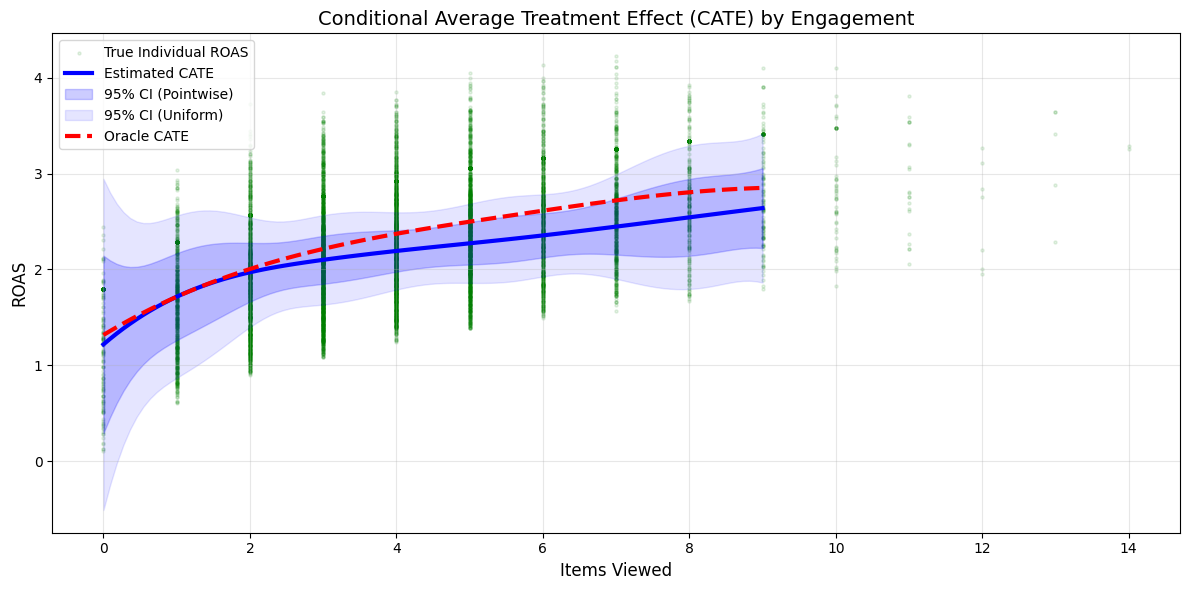

In [35]:
# Create grid for plotting
X_grid_engagement = np.linspace(df['items_viewed'].quantile(0.01), 
                                 df['items_viewed'].quantile(0.99), 100).reshape(-1, 1)
basis_grid_engagement = pd.DataFrame(spline_engagement.transform(X_grid_engagement), columns=basis_engagement_cols)

# Get CATE predictions with confidence intervals
cate_engagement_confint = cate_engagement_results.confint(basis_grid_engagement)
cate_engagement_uniform = cate_engagement_results.confint(basis_grid_engagement, joint=True)

# Oracle CATE (linear regression on true effects with spline basis)
oracle_model_engagement = LinearRegression().fit(basis_engagement, df['true_roas'])
oracle_cate_engagement = oracle_model_engagement.predict(basis_grid_engagement)

# Plot
plt.figure(figsize=(12, 6))

# True individual ROAS (scatter)
plt.scatter(df['items_viewed'], df['true_roas'], color='green', alpha=0.1, 
            s=5, label='True Individual ROAS')

# Estimated CATE curve with confidence bands
plt.plot(X_grid_engagement, cate_engagement_confint['effect'], color='blue', linewidth=3, 
         label='Estimated CATE')
plt.fill_between(X_grid_engagement.flatten(), cate_engagement_confint['2.5 %'], cate_engagement_confint['97.5 %'], 
                 color='blue', alpha=0.2, label='95% CI (Pointwise)')
plt.fill_between(X_grid_engagement.flatten(), cate_engagement_uniform['2.5 %'], cate_engagement_uniform['97.5 %'], 
                 color='blue', alpha=0.1, label='95% CI (Uniform)')

# Oracle CATE
plt.plot(X_grid_engagement, oracle_cate_engagement, color='red', linestyle='--', linewidth=3, 
         label='Oracle CATE')

plt.xlabel('Items Viewed', fontsize=12)
plt.ylabel('ROAS', fontsize=12)
plt.title('Conditional Average Treatment Effect (CATE) by Engagement', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Past Spending

We can estimate how ROAS varies continuously as a function of past spend using DoubleML's `cate()` method with spline basis functions.


In [36]:
# Fit spline
spline = SplineTransformer(n_knots=6, degree=3, include_bias=True, knots='uniform')

# Transform all values for CATE estimation
basis_raw = spline.fit_transform(df[['past_spend']])
basis_cols = [f'bs_{i}' for i in range(basis_raw.shape[1])]
basis = pd.DataFrame(basis_raw, columns=basis_cols)

# Estimate CATE
cate_results = dml_boost.cate(basis)
print("CATE Coefficients (Spline Basis):")
print(cate_results.summary)

CATE Coefficients (Spline Basis):
            coef    std err         t         P>|t|      [0.025      0.975]
bs_0    0.445629   7.220090  0.061721  9.507853e-01  -13.705489   14.596746
bs_1    3.778885   0.938088  4.028285  5.618515e-05    1.940267    5.617503
bs_2    1.981801   0.412145  4.808501  1.520659e-06    1.174011    2.789590
bs_3    2.227960   0.395574  5.632220  1.779043e-08    1.452649    3.003271
bs_4    1.623394   0.730190  2.223249  2.619900e-02    0.192248    3.054539
bs_5    2.092151   2.613251  0.800593  4.233672e-01   -3.029727    7.214030
bs_6   72.553731  18.545435  3.912215  9.145344e-05   36.205345  108.902116
bs_7 -258.745891  71.795052 -3.603952  3.134155e-04 -399.461608 -118.030174


In [37]:
# Create grid for plotting
X_grid = np.linspace(df['past_spend'].quantile(0.01), 
                     df['past_spend'].quantile(0.99), 100).reshape(-1, 1)
basis_grid = pd.DataFrame(spline.transform(X_grid), columns=basis_cols)

# Get CATE predictions with confidence intervals
cate_confint = cate_results.confint(basis_grid)
cate_uniform = cate_results.confint(basis_grid, joint=True)

cate_confint.head()

,2.5 %,effect,97.5 %
0,1.437405,2.923828,4.410252
1,1.598995,2.940422,4.281848
2,1.747346,2.954294,4.161243
3,1.882643,2.965539,4.048434
4,2.005036,2.974247,3.943457


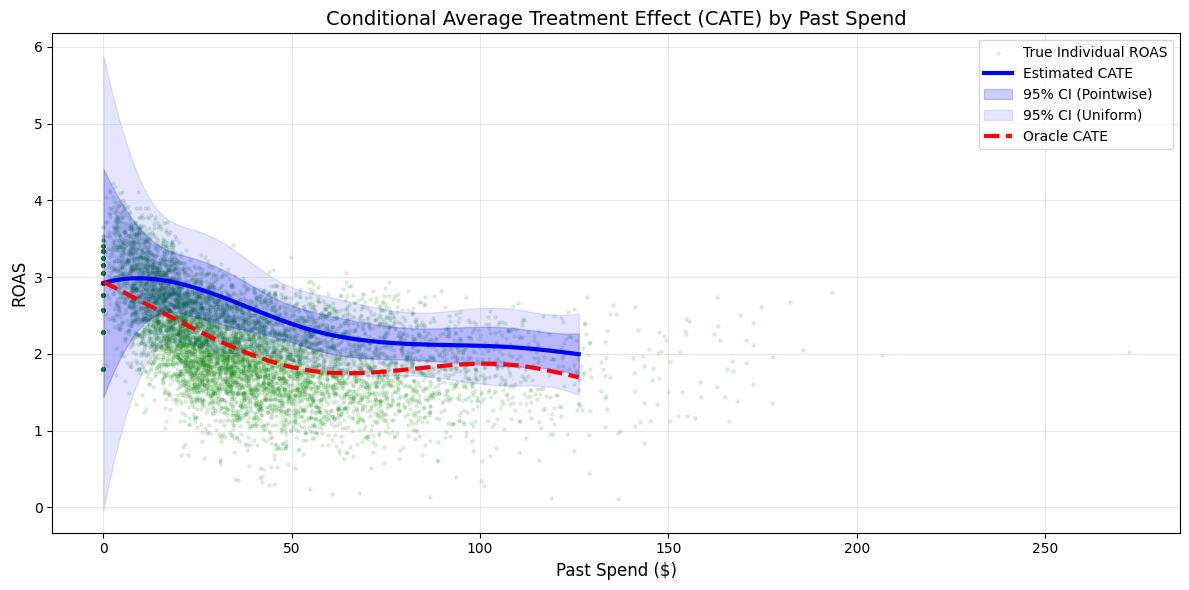

In [38]:
# Oracle CATE (linear regression on true effects with spline basis)
oracle_model = LinearRegression().fit(basis, df['true_roas'])
oracle_cate = oracle_model.predict(basis_grid)

# Plot
plt.figure(figsize=(12, 6))

# True individual ROAS (scatter)
plt.scatter(df['past_spend'], df['true_roas'], color='green', alpha=0.1, 
            s=5, label='True Individual ROAS')

# Estimated CATE curve with confidence bands
plt.plot(X_grid, cate_confint['effect'], color='blue', linewidth=3, 
         label='Estimated CATE')
plt.fill_between(X_grid.flatten(), cate_confint['2.5 %'], cate_confint['97.5 %'], 
                 color='blue', alpha=0.2, label='95% CI (Pointwise)')
plt.fill_between(X_grid.flatten(), cate_uniform['2.5 %'], cate_uniform['97.5 %'], 
                 color='blue', alpha=0.1, label='95% CI (Uniform)')

# Oracle CATE
plt.plot(X_grid, oracle_cate, color='red', linestyle='--', linewidth=3, 
         label='Oracle CATE')

plt.xlabel('Past Spend ($)', fontsize=12)
plt.ylabel('ROAS', fontsize=12)
plt.title('Conditional Average Treatment Effect (CATE) by Past Spend', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The choice of the basis function impacts which approximation of the cate we are estimating. Generally very different type of basis functions are possible. Some examples include:

- *Quantile Bin Dummies (Piecewise Constant):*
  This basis divides the range of past spend into quantile-based bins and creates dummy variables for each bin. The CATE is estimated as a constant within each bin, allowing for sharp changes but no smooth transitions (essentially GATEs for different dummies).

- *Piecewise Linear Spline (Degree=1):*
  Spline bases allow the CATE to change linearly between knots. With quantile-based knots, the model adapts to the data distribution and can capture gradual changes in effect. This is more flexible than bin dummies and can approximate nonlinear relationships.

- *Polynomial Basis:*
  Polynomial features (e.g., degree 3) model the CATE as a smooth curve over past spend. This can capture global nonlinear trends but may struggle with sharp local changes unless the degree is high.

For all these bases, as the sample size increases, the bias in the estimated CATE function decreases. With more data, the model can better estimate the true underlying effect, especially in regions with fewer observations.

Below, we fit and compare these basis functions. The estimated CATE curves approach the oracle (true) curve as the number of observations grows.

In [39]:
# Alternative basis constructions for CATE estimation with 'past_spend'
from sklearn.preprocessing import SplineTransformer, KBinsDiscretizer, PolynomialFeatures

# 1. Quantile bin dummies (piecewise constant)
kbins = KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile')
basis_bins = kbins.fit_transform(df[['past_spend']])
basis_bins_cols = [f'bin_{i}' for i in range(basis_bins.shape[1])]
basis_bins = pd.DataFrame(basis_bins, columns=basis_bins_cols)
cate_bins = dml_boost.cate(basis_bins)
print("CATE (Quantile Bin Dummies):")
print(cate_bins.summary)

# 2. Quantile-based piecewise linear spline (degree=1)
spline_quant = SplineTransformer(n_knots=6, degree=1, include_bias=True, knots='uniform')
basis_quant = spline_quant.fit_transform(df[['past_spend']])
basis_quant_cols = [f'bs_quant_{i}' for i in range(basis_quant.shape[1])]
basis_quant = pd.DataFrame(basis_quant, columns=basis_quant_cols)
cate_quant = dml_boost.cate(basis_quant)
print("\nCATE (Quantile-based Piecewise Linear Spline):")
print(cate_quant.summary)

# 3. Polynomial basis
poly = PolynomialFeatures(degree=3, include_bias=True)
basis_poly = poly.fit_transform(df[['past_spend']])
basis_poly_cols = poly.get_feature_names_out(['past_spend'])
basis_poly = pd.DataFrame(basis_poly, columns=basis_poly_cols)
cate_poly = dml_boost.cate(basis_poly)
print("\nCATE (Polynomial Basis on log(past_spend)):")
print(cate_poly.summary)

CATE (Quantile Bin Dummies):
           coef   std err          t          P>|t|    [0.025     0.975]
bin_0  7.574532  1.621312   4.671853   2.984949e-06  4.396818  10.752245
bin_1  2.653682  0.308897   8.590841   8.633496e-18  2.048255   3.259108
bin_2  2.745902  0.241594  11.365769   6.191679e-30  2.272387   3.219418
bin_3  2.658599  0.188702  14.088891   4.444864e-45  2.288750   3.028447
bin_4  2.113330  0.080010  26.413169  9.672301e-154  1.956512   2.270147

CATE (Quantile-based Piecewise Linear Spline):
                coef       std err             t         P>|t|    [0.025  \
bs_quant_0  3.274971  3.172996e-01  1.032138e+01  5.640518e-25  2.653075   
bs_quant_1  2.258878  1.419129e-01  1.591735e+01  4.802588e-57  1.980734   
bs_quant_2  2.118399  1.384252e-01  1.530357e+01  7.237607e-53  1.847091   
bs_quant_3  1.530444  2.628578e-01  5.822326e+00  5.803435e-09  1.015252   
bs_quant_4  7.206736  1.533636e+00  4.699117e+00  2.612889e-06  4.200864   
bs_quant_5  5.593531  1.06190

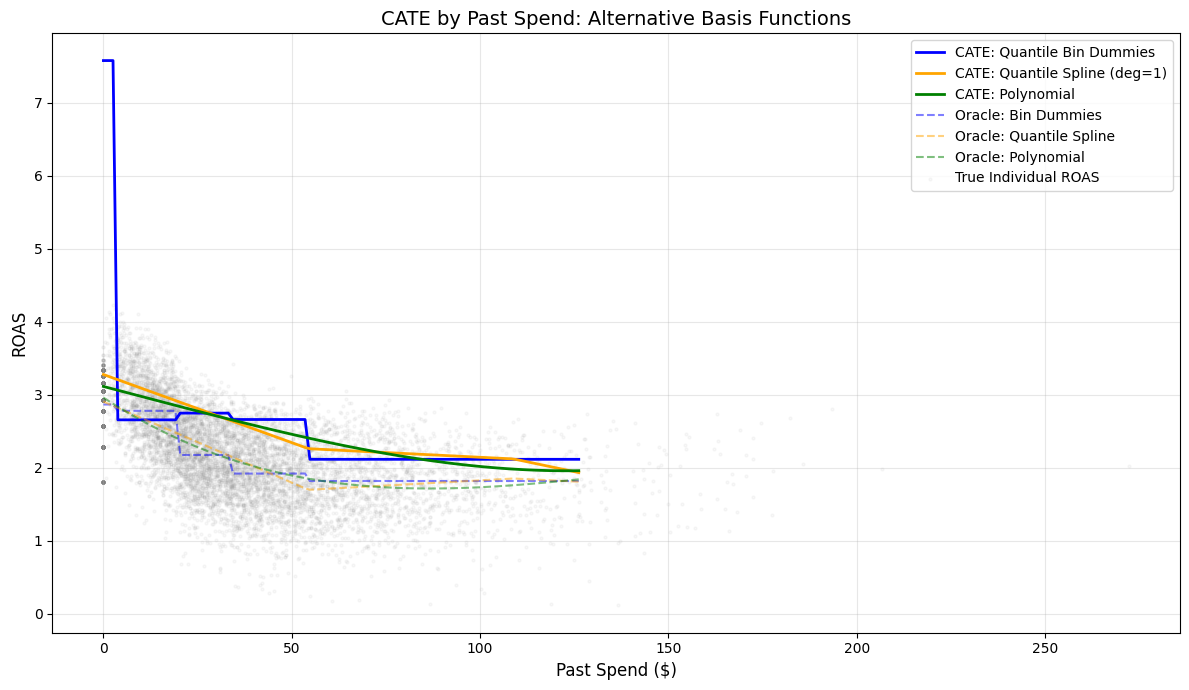

In [40]:
# Plot CATE curves for each basis (robust version)
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Create grid for plotting
X_grid = np.linspace(df['past_spend'].quantile(0.01), df['past_spend'].quantile(0.99), 100).reshape(-1, 1)

# 1. Quantile bin dummies (piecewise constant)
basis_grid_bins = pd.DataFrame(kbins.transform(X_grid), columns=basis_bins_cols)
cate_bins_pred = cate_bins.confint(basis_grid_bins)['effect']
oracle_bins = LinearRegression().fit(basis_bins, df['true_roas']).predict(basis_grid_bins)

# 2. Quantile-based piecewise linear spline (degree=1)
basis_grid_quant = pd.DataFrame(spline_quant.transform(X_grid), columns=basis_quant_cols)
cate_quant_pred = cate_quant.confint(basis_grid_quant)['effect']
oracle_quant = LinearRegression().fit(basis_quant, df['true_roas']).predict(basis_grid_quant)

# 3. Polynomial basis
basis_grid_poly = pd.DataFrame(poly.transform(X_grid), columns=basis_poly_cols)
cate_poly_pred = cate_poly.confint(basis_grid_poly)['effect']
oracle_poly = LinearRegression().fit(basis_poly, df['true_roas']).predict(basis_grid_poly)

plt.figure(figsize=(12, 7))
plt.plot(X_grid, cate_bins_pred, label='CATE: Quantile Bin Dummies', color='blue', linewidth=2)
plt.plot(X_grid, cate_quant_pred, label='CATE: Quantile Spline (deg=1)', color='orange', linewidth=2)
plt.plot(X_grid, cate_poly_pred, label='CATE: Polynomial', color='green', linewidth=2)
plt.plot(X_grid, oracle_bins, '--', color='blue', alpha=0.5, label='Oracle: Bin Dummies')
plt.plot(X_grid, oracle_quant, '--', color='orange', alpha=0.5, label='Oracle: Quantile Spline')
plt.plot(X_grid, oracle_poly, '--', color='green', alpha=0.5, label='Oracle: Polynomial')
plt.scatter(df['past_spend'], df['true_roas'], color='gray', alpha=0.05, s=5, label='True Individual ROAS')
plt.xlabel('Past Spend ($)', fontsize=12)
plt.ylabel('ROAS', fontsize=12)
plt.title('CATE by Past Spend: Alternative Basis Functions', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Sensitivity Analysis: Omitted Confounding

Sensitivity analysis helps assess how robust our causal effect estimates are to potential unobserved confounding. In DoubleML, the sensitivity analysis quantifies how much the estimated ROAS would change if there were omitted variables that explain additional variation in the outcome and/or treatment.

At first take a look at the $R^2$ values of our outcome and treatment models:

In [41]:
from sklearn.metrics import r2_score

print(f"Outcome R^2: {r2_score(df['revenue'], dml_boost.predictions['ml_l'].reshape(-1))}")
print(f"Treatment R^2: {r2_score(df['ad_spend'], dml_boost.predictions['ml_m'].reshape(-1))}")

Outcome R^2: 0.9415847826708561
Treatment R^2: 0.8113981565529623


The parameters `cf_y` and `cf_d` represent the proportion of residual variance in the outcome and treatment equations, respectively, that could be explained by an unobserved confounder. They are interpreted as R²-type measures: for example, `cf_y = 0.03` means a hypothetical confounder could explain 3% of the residual variation in the outcome, after controlling for observed covariates. Similarly, `cf_d = 0.03` means 3% of the residual variation in the treatment could be explained by the confounder.

By varying these parameters, we can evaluate how sensitive our causal conclusions are to possible omitted variable bias.

In [42]:
dml_boost.sensitivity_analysis(cf_y=0.03, cf_d=0.03, rho=1.0, level=0.95)
print(dml_boost.sensitivity_summary)

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
          CI lower  theta lower     theta  theta upper  CI upper
ad_spend  1.978174     2.091455  2.262927     2.434398  2.547977

------------------ Robustness Values ------------------
          H_0     RV (%)    RVa (%)
ad_spend  0.0  32.922978  31.261889


Instead a plot can highlight, different combinations of values for `cf_y` and `cf_d`, allowing us to visualize the potential impact of unobserved confounding on our causal estimates.


In [43]:
dml_boost.sensitivity_plot()

Benchmarking allows to obtain a "noisy" estimate of the confounding strength of known confounding variables. But this should only be used with good intuition.

In [44]:
dml_boost.sensitivity_benchmark(benchmarking_set=['days_since_visit'])

,cf_y,cf_d,rho,delta_theta
ad_spend,0.186744,0.363254,0.836833,1.050836
